# Poisson Distribution Assignment

**Task:** Generate Poisson samples using **5 different parameter values**, visualize the distributions, calculate probabilities, and calculate expected value.

A Poisson distribution is used for counting how many times an event happens in a fixed interval of time, space, or area.

The main parameter is **λ (lambda)**:

- λ = average number of events in the interval
- For a Poisson distribution: **Expected value = λ**
- Variance is also equal to **λ**


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Make results reproducible
np.random.seed(42)


## 1. Generate Poisson Samples with 5 Different Parameters

Here we use 5 different lambda values: **2, 5, 10, 15, and 20**.

These represent different average event rates. For example:

- λ = 2 means around 2 events are expected in the interval
- λ = 20 means around 20 events are expected in the interval


In [2]:
# Five different Poisson parameters
lambda_values = [2, 5, 10, 15, 20]

# Number of random samples for each lambda
sample_size = 1000

# Generate samples and store them in a dictionary
poisson_samples = {}

for lam in lambda_values:
    poisson_samples[lam] = np.random.poisson(lam=lam, size=sample_size)

# Convert samples into a DataFrame for easy viewing
samples_df = pd.DataFrame(poisson_samples)
samples_df.columns = [f"lambda_{lam}" for lam in lambda_values]

# Display first 10 rows
samples_df.head(10)


,lambda_2,lambda_5,lambda_10,lambda_15,lambda_20
0,4,4,16,10,25
1,1,3,15,19,12
2,3,5,13,12,24
3,3,3,11,18,21
4,1,3,11,17,26
5,2,7,7,17,22
6,1,4,10,21,31
7,1,4,13,19,26
8,2,6,11,10,14
9,2,6,13,17,15


## 2. Visualize the Poisson Distributions

The histogram shows the generated sample distribution.

The line with markers shows the theoretical Poisson PMF.


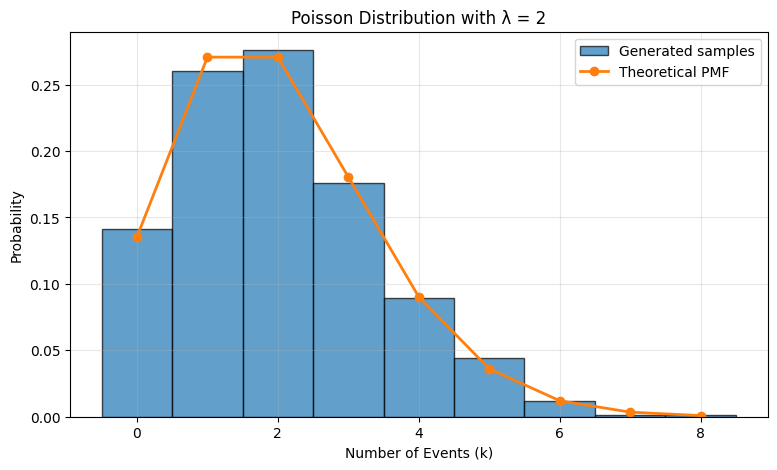

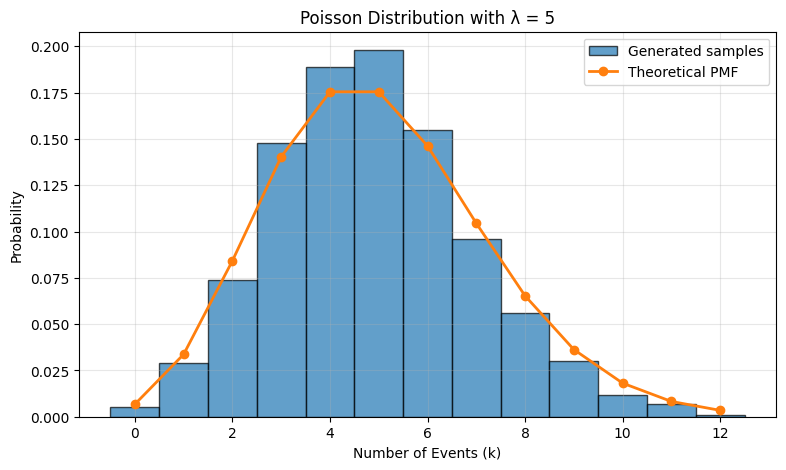

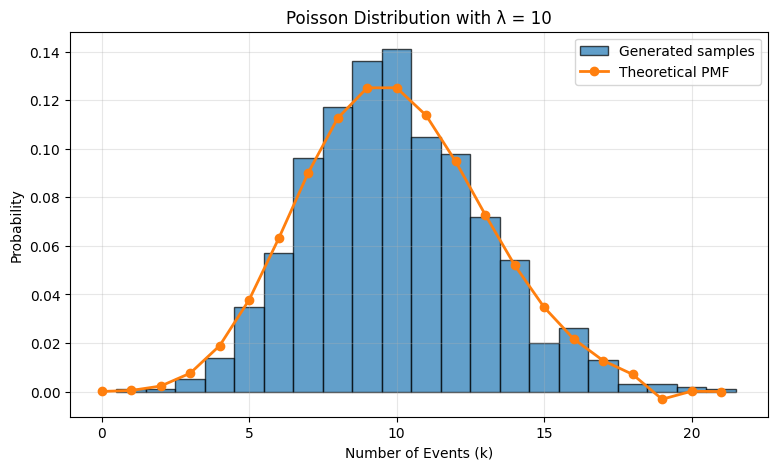

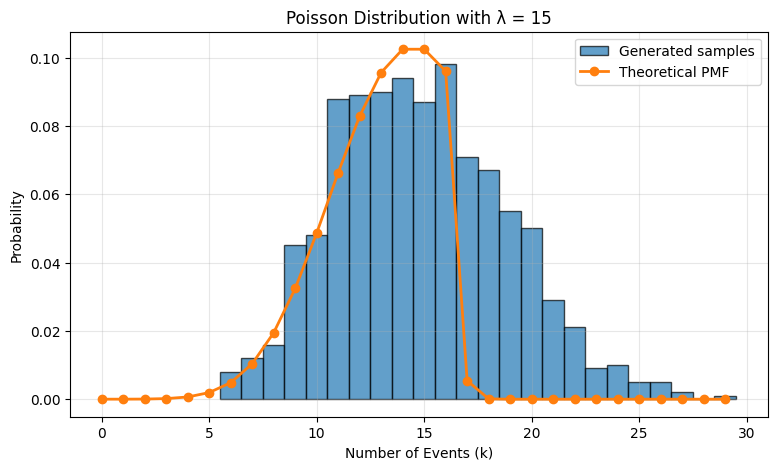

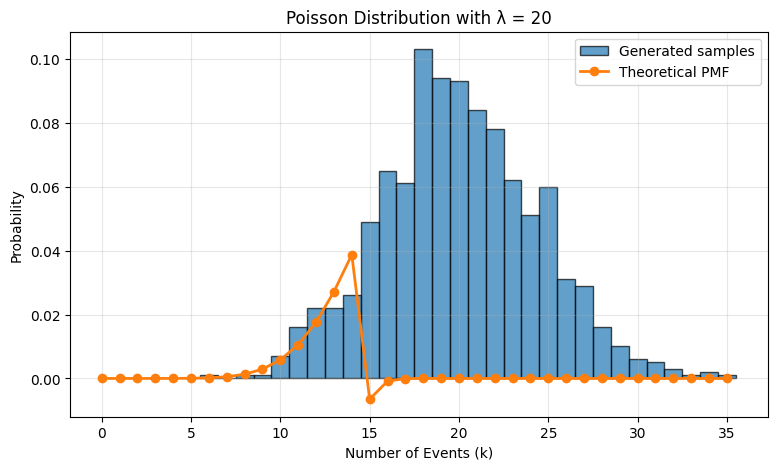

In [3]:
def poisson_pmf(k, lam):
    """Calculate Poisson PMF: P(X = k)."""
    return (lam ** k) * math.exp(-lam) / math.factorial(k)

# Plot each Poisson distribution separately
for lam in lambda_values:
    samples = poisson_samples[lam]
    x_values = np.arange(0, max(samples) + 1)
    pmf_values = [poisson_pmf(k, lam) for k in x_values]

    plt.figure(figsize=(9, 5))

    plt.hist(
        samples,
        bins=np.arange(min(samples), max(samples) + 2) - 0.5,
        density=True,
        edgecolor="black",
        alpha=0.7,
        label="Generated samples"
    )

    plt.plot(
        x_values,
        pmf_values,
        marker="o",
        linewidth=2,
        label="Theoretical PMF"
    )

    plt.title(f"Poisson Distribution with λ = {lam}")
    plt.xlabel("Number of Events (k)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 3. Calculate Probabilities

For each lambda value, we calculate useful probabilities:

- **P(X = λ)** → probability of getting exactly the average value
- **P(X ≤ λ)** → probability of getting up to the average value
- **P(X > λ)** → probability of getting more than the average value

For Poisson distribution, the value of `k` must be a whole number.


In [4]:
def poisson_cdf(k, lam):
    """Calculate Poisson CDF: P(X <= k)."""
    return sum(poisson_pmf(i, lam) for i in range(k + 1))

probability_results = []

for lam in lambda_values:
    k = int(lam)

    p_equal_k = poisson_pmf(k, lam)
    p_less_equal_k = poisson_cdf(k, lam)
    p_greater_k = 1 - p_less_equal_k

    probability_results.append({
        "Lambda (λ)": lam,
        "k value used": k,
        "P(X = k)": p_equal_k,
        "P(X ≤ k)": p_less_equal_k,
        "P(X > k)": p_greater_k
    })

probability_df = pd.DataFrame(probability_results)
probability_df


,Lambda (λ),k value used,P(X = k),P(X ≤ k),P(X > k)
0,2,2,0.270671,0.676676,0.323324
1,5,5,0.175467,0.615961,0.384039
2,10,10,0.125110,0.583040,0.416960
3,15,15,0.102436,0.568090,0.431910
4,20,20,0.088835,0.559093,0.440907


## 4. Calculate Expected Value

For a Poisson distribution:

**Expected Value = E(X) = λ**

So, if λ = 10, then the expected number of events is 10.

We also compare the theoretical expected value with the sample mean from our generated data.


In [5]:
expected_value_results = []

for lam in lambda_values:
    samples = poisson_samples[lam]

    expected_value_results.append({
        "Lambda (λ)": lam,
        "Theoretical Expected Value E(X)": lam,
        "Sample Mean": np.mean(samples),
        "Theoretical Variance": lam,
        "Sample Variance": np.var(samples, ddof=1)
    })

expected_value_df = pd.DataFrame(expected_value_results)
expected_value_df


,Lambda (λ),Theoretical Expected Value E(X),Sample Mean,Theoretical Variance,Sample Variance
0,2,2,2.003,2,2.006998
1,5,5,4.896,5,4.153337
2,10,10,9.965,10,8.994770
3,15,15,14.854,15,15.840525
4,20,20,20.019,20,19.281921


## 5. Combined Comparison Graph

This graph helps us compare all 5 Poisson distributions together.

As λ increases, the distribution moves to the right and becomes more spread out.


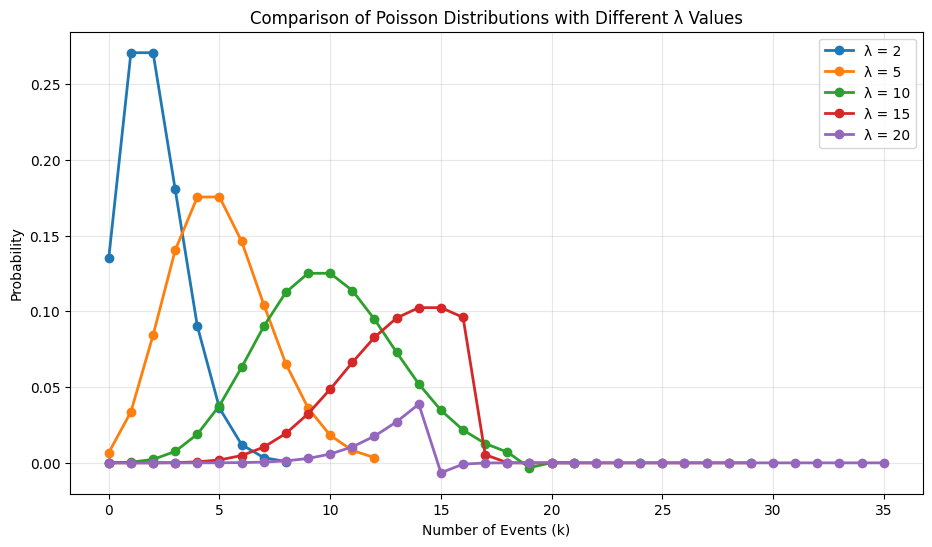

In [6]:
plt.figure(figsize=(11, 6))

for lam in lambda_values:
    samples = poisson_samples[lam]
    x_values = np.arange(0, max(samples) + 1)
    pmf_values = [poisson_pmf(k, lam) for k in x_values]
    plt.plot(x_values, pmf_values, marker="o", linewidth=2, label=f"λ = {lam}")

plt.title("Comparison of Poisson Distributions with Different λ Values")
plt.xlabel("Number of Events (k)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Conclusion

This notebook generated Poisson samples using five different lambda values: **2, 5, 10, 15, and 20**.

The visualizations show that when lambda increases, the distribution shifts to the right because the average number of expected events increases.

The probability table shows exact, cumulative, and greater-than probabilities for each lambda value.

The expected value table confirms the main Poisson rule:

**Expected Value = λ**
